## Stanisław Wojciechowski
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vyenn/ML2024/blob/main/homework4.ipynb)

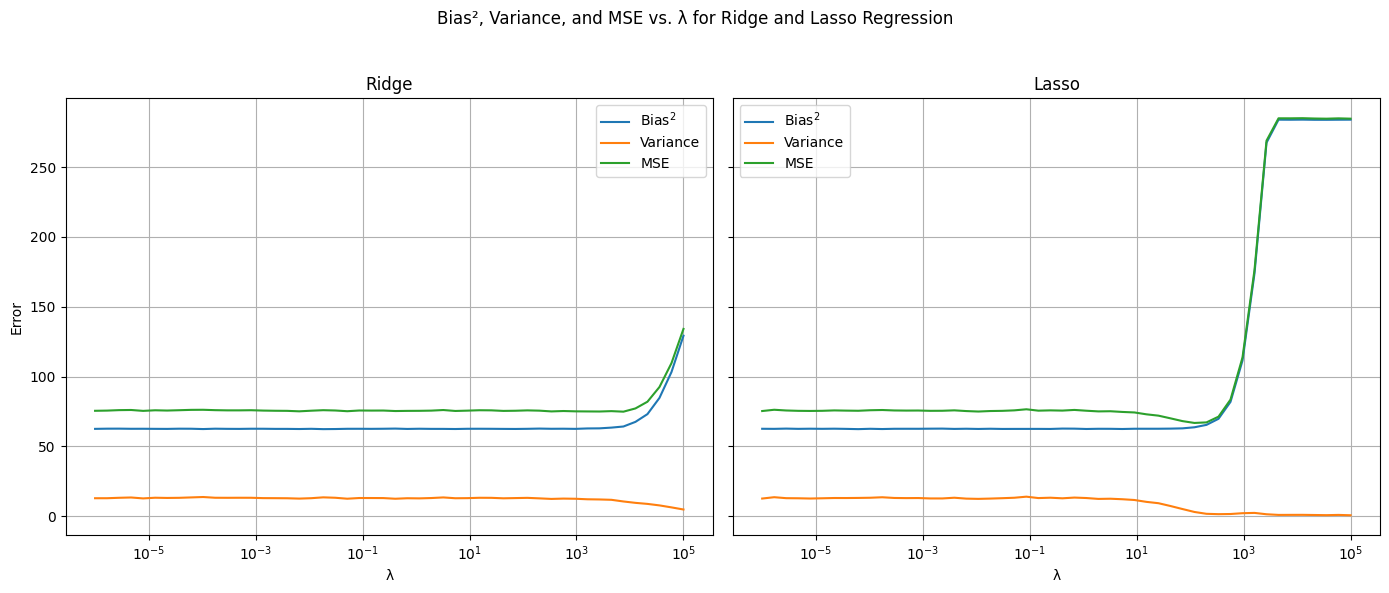

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso

# Reproducibility
np.random.seed(42)

# Synthetic dataset parameters
n_train, n_test = 300, 3000
n_features, n_non_zero = 50, 5
sigma = 8.0

# Generate beta with n_non_zero nonzero coefficients
beta_true = np.zeros(n_features)
beta_true[np.random.choice(n_features, n_non_zero, replace=False)] = np.random.uniform(1, 10, size=n_non_zero)

# Generate test dataset
X_test = np.random.randn(n_test, n_features)
y_test = X_test.dot(beta_true) + np.random.normal(scale=sigma, size=n_test)

# Regularization parameter range
lambdas = np.logspace(-6, 5, 50)
alphas = lambdas / n_train
n_repeats = 100

metrics = {
    'ridge': {'bias2': [], 'variance': [], 'mse': []},
    'lasso': {'bias2': [], 'variance': [], 'mse': []}
}

# Train and get bias2,variance,mse vs lambda
for model_type in ['ridge', 'lasso']:
    for alpha in alphas:
        predictions = np.zeros((n_repeats, len(y_test)))

        for rep in range(n_repeats):
            X_train = np.random.randn(n_train, n_features)
            noise = np.random.normal(scale=sigma, size=n_train)
            y_train = X_train.dot(beta_true) + noise
            model = Ridge(alpha=alpha) if model_type == 'ridge' else Lasso(alpha=alpha, max_iter=10000)
            model.fit(X_train, y_train)
            predictions[rep] = model.predict(X_test)

        mean_pred = np.mean(predictions, axis=0)
        bias2 = np.mean((mean_pred - y_test)**2)
        variance = np.mean(np.var(predictions, axis=0))
        mse = np.mean((predictions - y_test)**2)

        metrics[model_type]['bias2'].append(bias2)
        metrics[model_type]['variance'].append(variance)
        metrics[model_type]['mse'].append(mse)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, model_type in enumerate(['ridge', 'lasso']):
    ax = axes[i]
    ax.plot(lambdas, metrics[model_type]['bias2'], label='Bias$^2$')
    ax.plot(lambdas, metrics[model_type]['variance'], label='Variance')
    ax.plot(lambdas, metrics[model_type]['mse'], label='MSE')
    ax.set_xscale('log')
    ax.set_xlabel('λ')
    ax.set_title(model_type.capitalize())
    ax.legend()
    ax.grid(True)

axes[0].set_ylabel('Error')
plt.suptitle('Bias², Variance, and MSE vs. λ for Ridge and Lasso Regression')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Answers

**Investigate how increasing  $\lambda$  influences the model’s bias, variance, and Mean Squared Error (MSE):**
- with $\lambda$ inscreasing bias increases, variance decreases as expected - enforcing a stronger penalty should result in a simpler model and with higher bias (since we put proportionally less weight to actually minimizing MSE)
- the most significant change happens after lambda reaches 10^3 in ridge and 10^2 in lasso
- MSE stays roughly constant for lambdas up to 10^3 in ridge and 10^2 in Lasso. Then it in both cases it forms a U-shape revealing the optimal trade-off

**Analyze how Ridge and Lasso differ in terms of their bias-variance trade-offs:**
- Lasso has a more visible U-shape. We can also see that the optimal MSE for Lasso is smaller than the optimal MSE for ridge. This is expected since we designed our dataset to be sparse and lasso is more likely to kill more variables, rather than scaling them close to zero like Ridge does

**Discuss situations where one method may outperform the other, considering factors like feature sparsity and multicollinearity:**
-in general, where we expect the dataset to be sparse, Lasso should outperform Ridge due to reasons stated above. On the contrary, when we expect multicollinearity it's better to use Ridge since it evenly distributes weights among correlated features rather than arbitrarily selecting one, as Lasso does.